In [ ]:
! pip install scanpy leidenalg --quiet

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

## Can machines learn to recognize meaningful patterns?

**Our question today:** Can a machine learn to recognize immune cell types without anyone telling it what to look for?

We will be using single-cell RNA sequencing (scRNA-seq) data from human blood cells to answer this question.


---
## Section 1: The Data

### What does the data look like?

Single-cell RNA sequencing gives us a **cell x gene matrix**:
- Each **row** is one cell
- Each **column** is one gene
- Each **value** is how much that gene is expressed in that cell (a count)

The data is stored in a format called `AnnData` — it holds the matrix plus metadata about the cells and genes.

In [ ]:
# load the dataset
url = "https://raw.githubusercontent.com/rikaaaac/comp-bio-erc-workshop/main/pbmc_10k.h5ad"
! wget -q -O /tmp/pbmc_10k.h5ad "{url}"
adata = sc.read_h5ad("/tmp/pbmc_10k.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 9506 × 38606
    var: 'gene_ids', 'feature_types', 'genome'


In [ ]:
# how many cells and genes do we have?
n_cells, n_genes = adata.shape
print(f"cells: {n_cells}")
print(f"genes: {n_genes}")

cells: 9506
genes: 38606


---
## Section 2: Pre-processing

### Data cleaning

Before any ML algorithm can work well, the data needs to be cleaned. Raw scRNA-seq data has two common problems:

1. **Low-quality cells** — some cells are damaged, dead, or empty
2. **Raw counts are not comparable** — one cell might have been sequenced more deeply than another, making it look like it expresses more genes just due to technical variation

We fix this with three steps:
- **Filter:** remove cells with too few genes detected (likely empty) and genes seen in too few cells (likely noise)
- **Normalize:** scale each cell so all cells have the same total count to removes sequencing depth bias
- **Log-transform:** compress the range of values to deal with skewed distributions

In [ ]:
# filter: remove low-quality cells and rarely-detected genes
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print(f"after filtering: {adata.shape[0]} cells, {adata.shape[1]} genes")

after filtering: 9462 cells, 25215 genes


Text(0.5, 0, 'count')

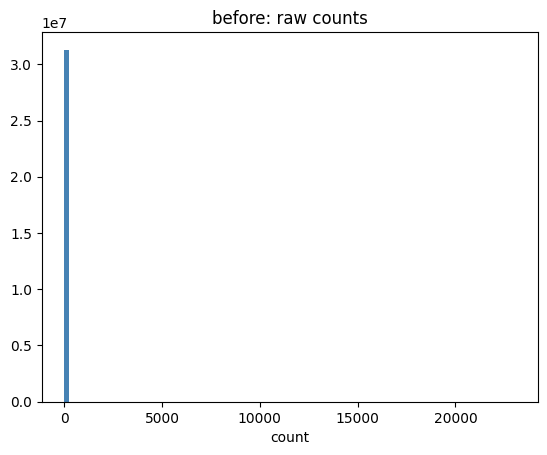

In [ ]:
# viewing raw counts distribution
raw_counts = adata.X.toarray().flatten()

# view histogram
plt.hist(raw_counts[raw_counts > 0], bins=100, color='steelblue')
plt.title('before: raw counts')
plt.xlabel('count')

In [ ]:
# normalize: make each cell's total counts equal
sc.pp.normalize_total(adata)

# log-transform: compress the scale
sc.pp.log1p(adata)

Text(0.5, 0, 'count')

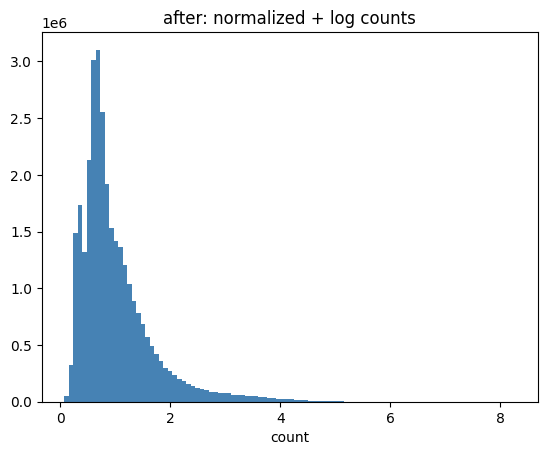

In [ ]:
log_counts = adata.X.toarray().flatten()

# view histogram
plt.hist(log_counts[log_counts > 0], bins=100, color='steelblue')
plt.title('after: normalized + log counts')
plt.xlabel('count')

---
## Section 3: Dimensionality Reduction (Part 1): PCA

### ML concept: linear dimensionality reduction

We now have ~9,500 cells, each described by 2,000 numbers (gene expression values). We want to group similar cells together, but comparing in a 2,000-dimensional space is computationally expensive and hard to interpret.

**Principal Component Analysis (PCA)** compresses the data into a smaller number of dimensions while keeping as much information as possible. It works by finding the directions in the data with the most variation.

The result is a set of **principal components (PCs)**, where each one is a combination of genes that captures a source of variation. PC1 captures the most variation, PC2 the next most, and so on.

In [ ]:
# run PCA, reduce to 50 components
sc.tl.pca(adata, n_comps=50)

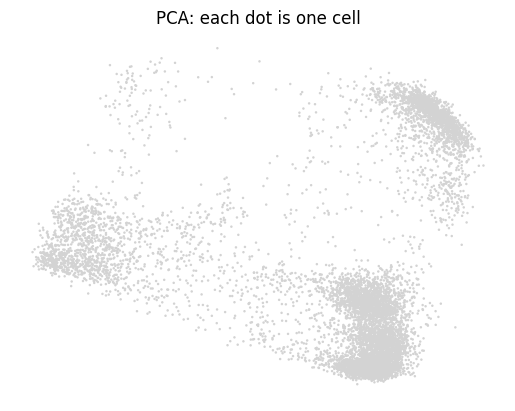

In [ ]:
# plot the first two principal components
# each dot is a cell; nearby cells have similar gene expression
sc.pl.pca(adata, title='PCA: each dot is one cell', frameon=False)

---
## Section 4: Dimensionality Reduction (Part 2): UMAP

### ML concept: non-linear dimensionality reduction

**UMAP (Uniform Manifold Approximation and Projection)** is another way to compress high-dimensional data into 2D, but unlike PCA, it can capture curved, non-linear structure.

How it works (intuitively): UMAP builds a graph where each cell is connected to its nearest neighbors. It then tries to draw a 2D map that preserves those neighborhood relationships as faithfully as possible.

**Key difference from PCA:**
- PCA preserves global distances
- UMAP preserves local neighborhoods
- UMAP is used for **visualization**, not for analysis. The distances between clusters are not meaningful, only the groupings within clusters are.

First we build the neighbor graph (using the PCA-compressed data), then we run UMAP on that graph.

In [ ]:
# build a graph using the top 50 pcs
sc.pp.neighbors(adata, n_pcs=50)

# run UMAP
sc.tl.umap(adata)

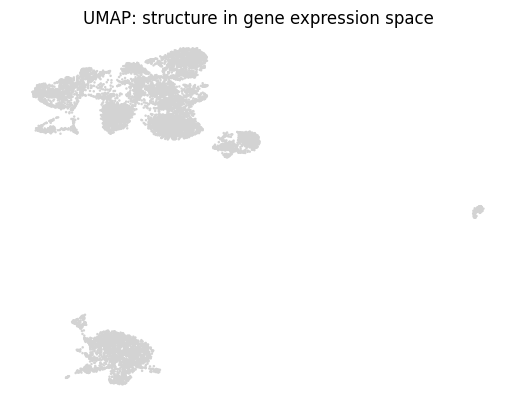

In [ ]:
# visualize — islands of cells with similar gene expression are now visible
sc.pl.umap(adata, title='UMAP: structure in gene expression space', frameon=False)

---
## Section 5: Clustering

### ML concept: unsupervised clustering

Now we want to formally assign each cell to a group. This is **unsupervised clustering**.

The `resolution` parameter controls granularity:
- **Low resolution** -> fewer, larger clusters
- **High resolution** -> more, smaller clusters

In [ ]:
# run Leiden clustering
sc.tl.leiden(adata, resolution=0.3, flavor='igraph', random_state=0)

print(f"number of clusters found: {adata.obs['leiden'].nunique()}")

number of clusters found: 13


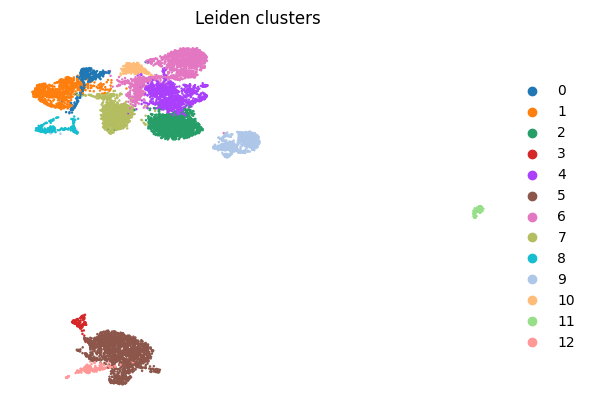

In [ ]:
# visualize clusters on the UMAP
sc.pl.umap(adata, color='leiden', title='Leiden clusters', frameon=False)

In [1]:
# try clustering with resolution that will yield higher clusters and plot them

---
## Section 6: Validation

### Model interpretation and validation

An ML model that finds patterns is only useful if those patterns are real and meaningful. We validate our clusters by checking whether they express **known marker genes**, which are genes that biologists have established are specific to particular cell types.

If the algorithm's clusters align with known biology, we can trust that it found something real.

| Cell type | Marker genes |
|-----------|-------------|
| T cells | CD3D, CD3E |
| CD4 T cells | CD4 |
| CD8 T cells | CD8A |
| B cells | CD19, MS4A1 |
| Monocytes | CD14, LYZ |
| NK cells | GNLY, NKG7 |

We will use two visualizations:
- **Dot plot:** shows average expression and fraction of cells expressing each marker per cluster
- **UMAP colored by gene:** shows where high-expressing cells sit in the map

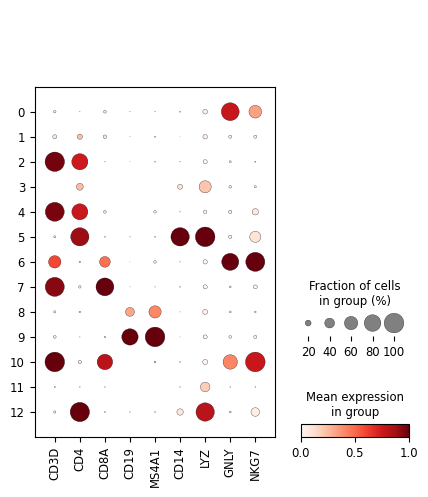

In [ ]:
marker_genes = ['CD3D', 'CD4', 'CD8A', 'CD19', 'MS4A1', 'CD14', 'LYZ', 'GNLY', 'NKG7']

sc.pl.dotplot(adata, marker_genes, groupby='leiden', standard_scale='var')

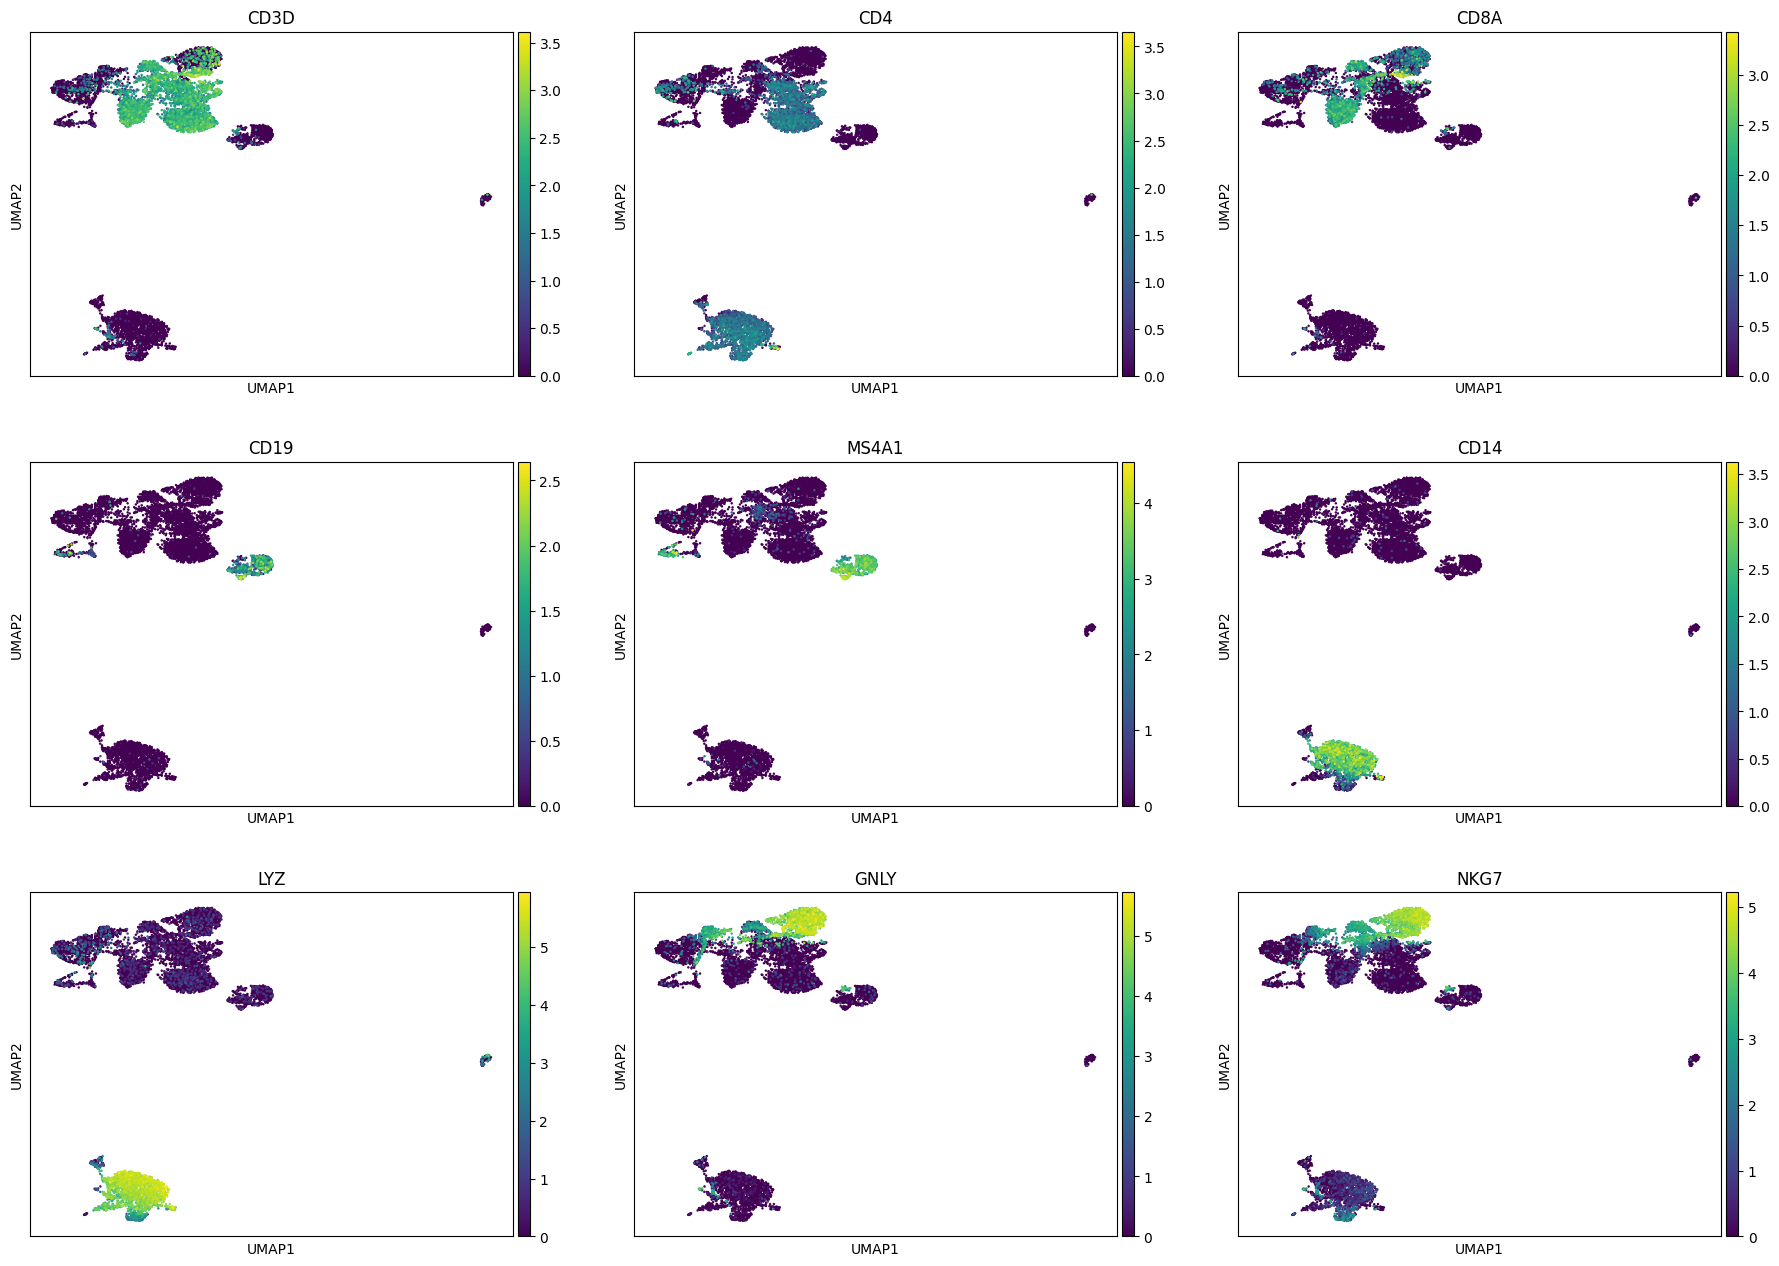

In [ ]:
# show where each marker gene is expressed on the UMAP
sc.pl.umap(adata, color=marker_genes, ncols=3)

---
## Summary

We just went from a raw matrix of ~9,500 cells x ~20,000 genes to a labeled map of immune cell types. Here is every method we used and what problem it solved:

| Step | Method | Concepts | What it does |
|------|--------|------------|--------------|
| 1 | Filter + normalize + log | Data cleaning | Remove noise, make cells comparable |
| 2 | PCA | Unsupervised learning: Linear dimensionality reduction | Compress features into a lower dimension |
| 3 | UMAP | Unsupervised learning: Non-linear dimensionality reduction | Visualize structure in 2D |
| 4 | Leiden clustering | Unsupervised learning: clustering | Group similar cells without labels |
| 5 | Marker genes + dot plot | Model validation | Confirm clusters match known biology |

This same pipeline is used to:
- Find new cell subtypes that no one has described before
- Compare healthy vs diseased tissue to find what has changed
- Identify which cell types respond to a drug or vaccine
- Predict patient outcomes from immune cell composition